## Paper

In [1]:
from matplotlib import pyplot as plt
import numpy as np

from predhpc import paper
from predhpc.util import plot_util

%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
paper.initialize_paper_parameters(gen_dir="..", notebook=True)
ALL_FIGURES = dict()

### Fig. 1: Background

In [4]:
Pyrs = paper.get_linear_Pyrs()

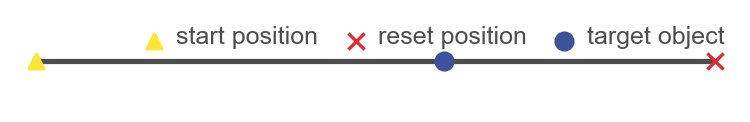

In [5]:
sub_ax = paper.plot_environment(Ag=Pyrs.Agent)
ALL_FIGURES["1B"] = sub_ax

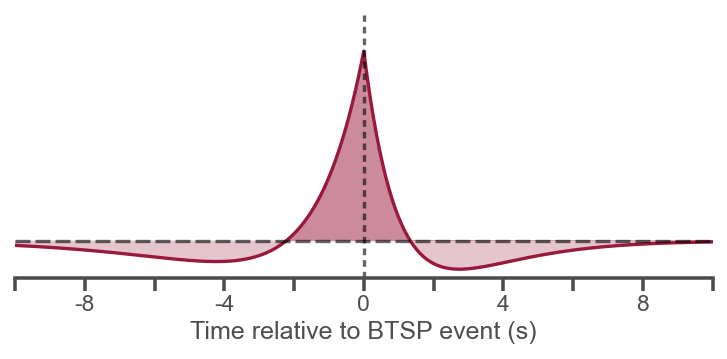

In [6]:
sub_ax = paper.plot_BTSP_kernel(Pyrs)
ALL_FIGURES["1D"] = sub_ax

### Fig. 2: Linear track

In [7]:
linear_learner = paper.run_linear(max_time_min=1.8)

 17%|██████▊                                | 625/3600 [00:00<00:03, 869.33it/s]

BTSP event recorded at step 513 (15.39 sec).


 37%|█████████████▉                        | 1320/3600 [00:01<00:02, 796.07it/s]

BTSP update applied at step 1207 (36.21 sec).


100%|██████████████████████████████████████| 3600/3600 [00:05<00:00, 714.30it/s]


Finishing last trajectory.


1131it [00:01, 700.86it/s]

Only reached target 4 times (target: 10).
Trajectory lengths (5) to date: 28.39 +/- 15.36 sec each
Trajectory lengths (5) to date: 946.40 +/- 511.95 steps each
1 BTSP event triggered (allowed from steps 0 to 4731): occurred at step 513.


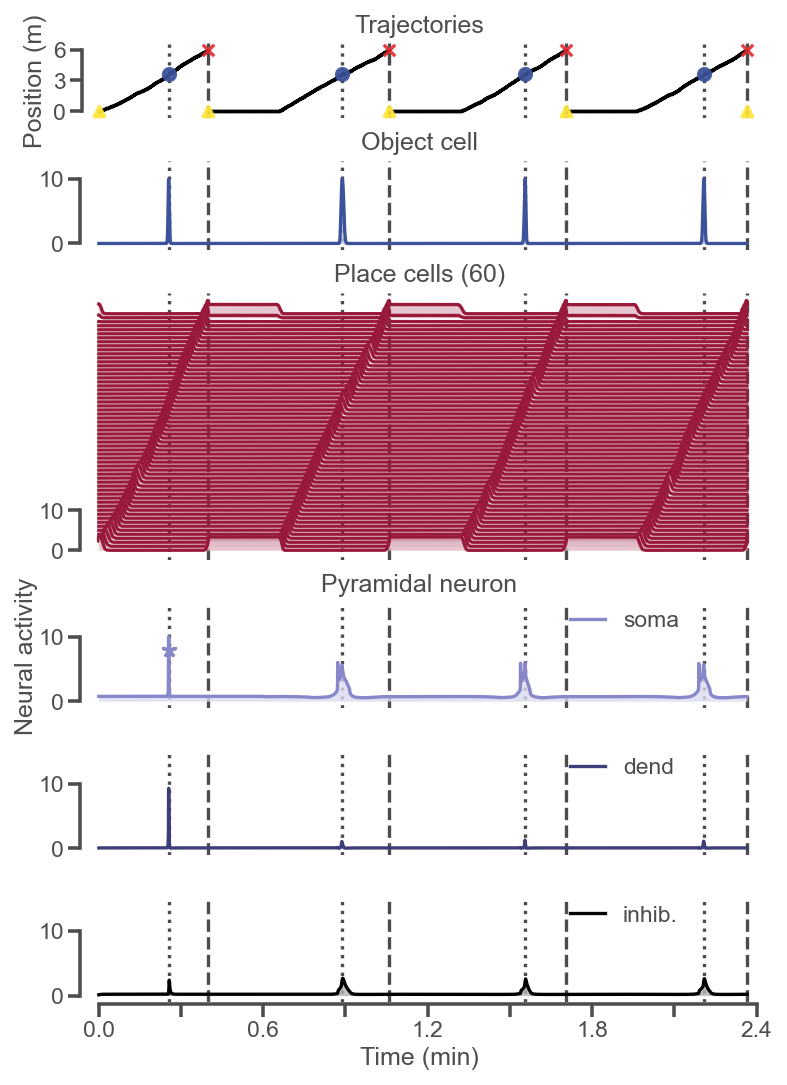

In [8]:
ax1D = paper.plot_linear_summary(linear_learner)
ALL_FIGURES["2A"] = ax1D

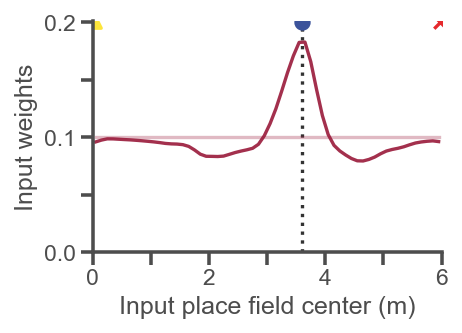

In [9]:
sub_ax = paper.plot_linear_PFs(linear_learner)
ALL_FIGURES["2B"] = sub_ax

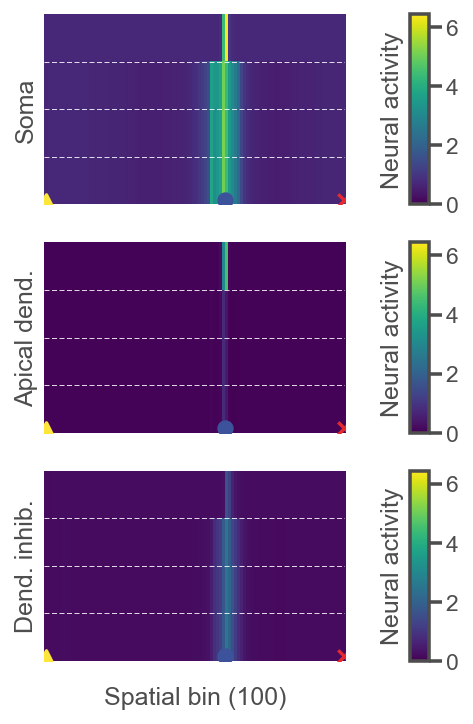

In [10]:
ax1D = paper.plot_linear_binned_rates(linear_learner)
ALL_FIGURES["2C"] = ax1D

### Fig. 3: Speed and PF width
Takes about 2.5 min to rerun.  
Note for comparison to data: the place field figures show input weights, not effective field as measured in pyramidal neuron.

In [11]:
speed_data = paper.run_linear_fct("linear_speeds", overwrite=False)

Loading data from ../results/paper/speed_data_18.npz.


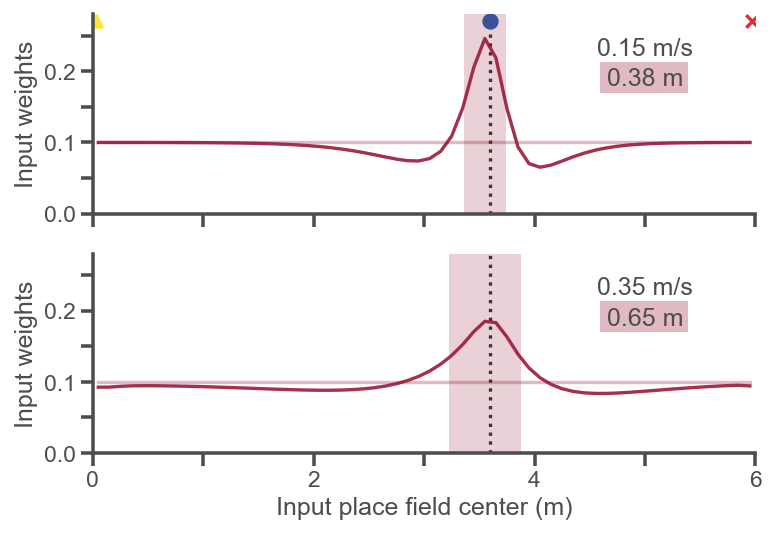

In [12]:
ax1D = paper.plot_linear_speed_PF_examples(speed_data)
ALL_FIGURES["3A"] = ax1D

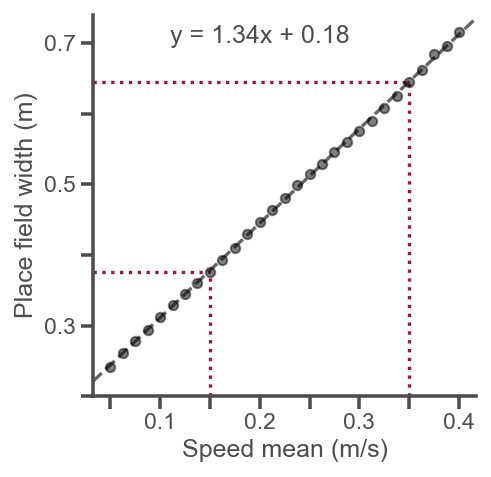

In [13]:
sub_ax = paper.plot_linear_speed_PF_widths(speed_data)
ALL_FIGURES["3B"] = sub_ax

### Fig. 4: Effect of linear shifts
Takes about 5 min to rerun.

In [14]:
shift_data = paper.run_linear_fct("linear_shifts", overwrite=False)

Loading data from ../results/paper/shift_data_18.npz.


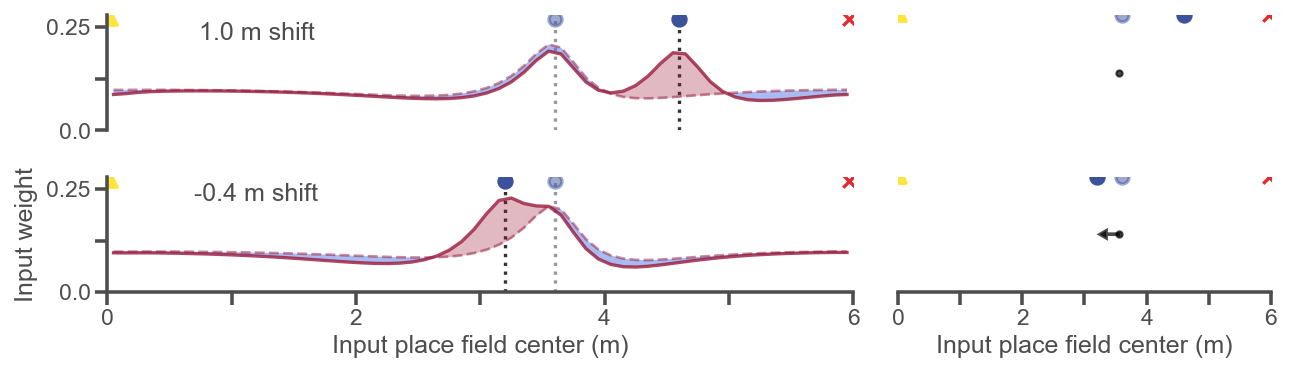

In [15]:
axes = paper.plot_linear_shift_PF_examples(shift_data)
ALL_FIGURES["4A"] = axes

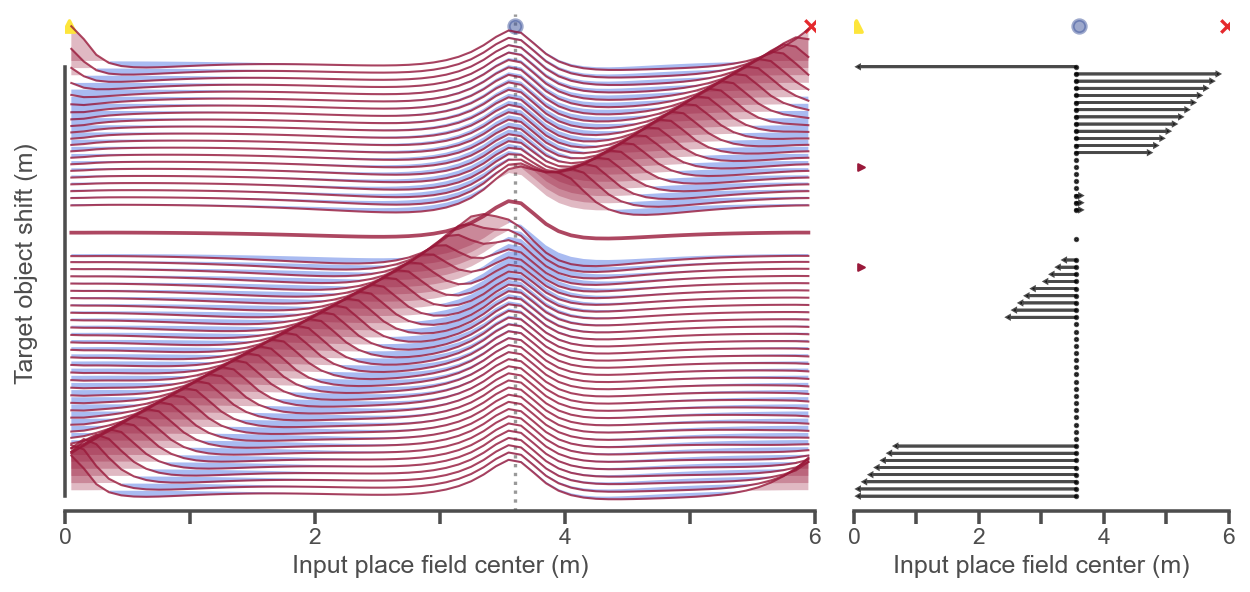

In [16]:
ax1D = paper.plot_target_shift_PFs(shift_data)
ALL_FIGURES["4B"] = ax1D

### Fig. 5: 2D environment and teleportation

In [17]:
import copy

from predhpc import plot_fcts, run_manager
from predhpc.util import params_util, gen_util, ext_util

In [18]:
gen_util.seed_all(paper.PAPER_SEED)

Pyr_params = params_util.get_Pyr_params(
    environment="openfield_corridor",
    log_BTSP=True
)

learner = run_manager.learn_openfield_BTSP(
    Pyr_params=Pyr_params,
    corridor=True,
    max_num_steps=15000,
    weight_recording_freq=1000,
    teleportation_enabled=False,
)

  8%|██▊                                  | 1159/15000 [00:03<00:41, 330.65it/s]

BTSP event recorded at step 1095 (32.85 sec).


 12%|████▌                                | 1847/15000 [00:05<00:40, 324.92it/s]

BTSP update applied at step 1789 (53.67 sec).


100%|████████████████████████████████████| 15000/15000 [00:39<00:00, 380.67it/s]

Reached target 27 times.
Trajectory lengths (8) to date: 56.25 +/- 9.92 sec each
Trajectory lengths (8) to date: 1875.00 +/- 330.72 steps each
1 BTSP event triggered (allowed from steps 0 to 14999): occurred at step 1095.


NameError: name 'PC_fields_sub_ax' is not defined

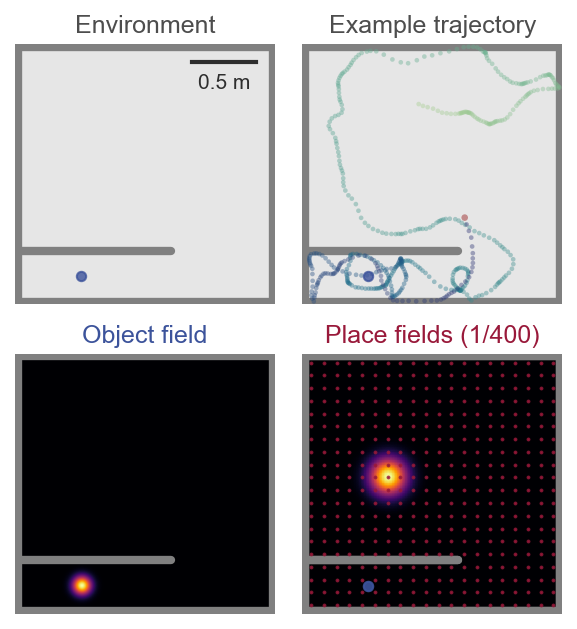

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(3.8, 3.8), gridspec_kw={"wspace": 0.015, "hspace": 0.19})
Env, Ag, PCs, Objs = ext_util.extract_objects_from_Pyrs(learner.Pyrs)
updater = run_manager.VNUpdater(Ag)

kwargs = {
    "skip_object_types": ["teleport"],
    "no_legend": True
}
y = 1.02
chosen_PCs = [206]

env_sub_ax, traj_sub_ax = axes[0]
Obj_sub_ax, PC_sub_ax = axes[1]

# top row
env_sub_ax.set_title("Environment", y=y)
Env.plot_environment(sub_ax=env_sub_ax, scale_loc=(1.62, 1.88), scale_length=0.5, **kwargs)

traj_sub_ax.set_title("Example trajectory", y=y)
traj_idx = 4
t_start = Ag.trajectory_df.loc[traj_idx, "start_time"] + 1
t_end = Ag.trajectory_df.loc[traj_idx, "stop_time"]
t_end = min(t_end, t_start + 90)
Ag.plot_trajectories(
    sub_ax=traj_sub_ax, t_start=t_start, t_end=t_end, framerate=8, alpha=0.4, s_2D=5, cmap_per=True, 
    plot_target=False, plot_agent=False, **kwargs
)

# bottom row
Obj_sub_ax.set_title("Object field", y=y, color=Objs.color)
Objs.plot_rate_map(sub_ax=Obj_sub_ax, plot_objects=False, colorbar=False, **kwargs)

PC_sub_ax.set_title(f"Place fields ({len(chosen_PCs)}/{PCs.n})", y=y, color=PCs.color)
Env.plot_environment(sub_ax=PC_sub_ax, plot_objects=True, **kwargs)
plot_fcts.plot_overlayed_rate_maps(PCs, sub_ax=PC_sub_ax, method="max", chosen_neurons=chosen_PCs, colorbar=False)
PCs.plot_place_cell_locations(sub_ax=PC_sub_ax, plot_objects=True, s=3, alpha=0.8, marker=".", **kwargs)

cbar_axlist = [Obj_sub_ax, PC_fields_sub_ax]
vmin = min([sub_ax.get_images()[-1].get_clim()[0] for sub_ax in cbar_axlist])
vmax = max([sub_ax.get_images()[-1].get_clim()[1] for sub_ax in cbar_axlist])
for sub_ax in cbar_axlist:
    im = sub_ax.get_images()[-1]
    im.set_clim(vmin, vmax)

cbar_axis = axes.ravel()[-1]
plot_util.add_colorbars(cbar_axis, cbar_axis.get_images()[-1], vmin=vmin, vmax=vmax, label="Neural activity")

for sub_ax in axes.ravel()[:-1]:
    plot_util.add_dummy_colorbar_axis(sub_ax)

ALL_FIGURES["5A-F"] = axes

In [ ]:
fig, sub_ax = plt.subplots(figsize=(2.7, 2.7))
plot_fcts.plot_2D_input_place_cell_weights(
    learner.Pyrs.SomaCompartment, alpha=0.6, s=79.35, obj_s=30, BTSP_s=30, BTSP_marker=(5, 2, 0), lw=1.6, plot_BTSP_events=True, 
    skip_object_types=["teleport"], no_legend=True, ax=sub_ax, marker="s", cbar_side="right", vmin=0
)
fig.axes[-1].set_ylabel("Input weights")

ALL_FIGURES["5G"] = sub_ax

In [ ]:
fig, sub_ax = plt.subplots(figsize=(10.4, 1.7))
learner.Pyrs.SomaCompartment.plot_rate_timeseries(sub_ax=sub_ax, lw=1.6, norm_by="none", mark_BTSP=False)
sub_ax.set_ylim(-2, 14.5)
learner.Pyrs.SomaCompartment.add_BTSP_markers_to_plots(ax=sub_ax, s=35, prop_y=0.78, lw=1.6, marker=(5, 2, 0), timeseries=True)
sub_ax.set_ylabel("")
plot_util.expand_ticks(sub_ax, axis="x", num_ticks=7, alternating=True, round_dec=1)
learner.Pyrs.Agent.add_position_across_time_to_plot(sub_ax=sub_ax, position_name="target", alpha=0.8, y=13.6)

paper.configure_neural_activity_axis(sub_ax)
plot_util.pad_axis(sub_ax, axis="x", pad_prop=0.015, prop_high=0)

ALL_FIGURES["5H"] = sub_ax

### Fig. 6: Teleportation

A: Teleportation ports  
B: Teleportation trajectory  
C: Remapped place field

### Fig. 7: Multiple targets

A: environment with multiple objects  
B: object fields  
C: trajectory examples  
D: 5 examples PFs  
E: all place fields overlaid  
F: BTSP events  
G: relationship between visits and number of BTSP events  

### Fig. 8: Remapping

A: remapping  
B: remapped  
C: correlation pre post

### Save figures

In [ ]:
SAVE = True

In [ ]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        if isinstance(ax, np.ndarray):
            fig = ax.ravel()[0].figure
        else:
            fig = ax.figure
        plot_util.save_figure(fig, key, no_timestamp=True)